In [13]:
import folium
import numpy as np
import pandas as pd
import commons as me
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go

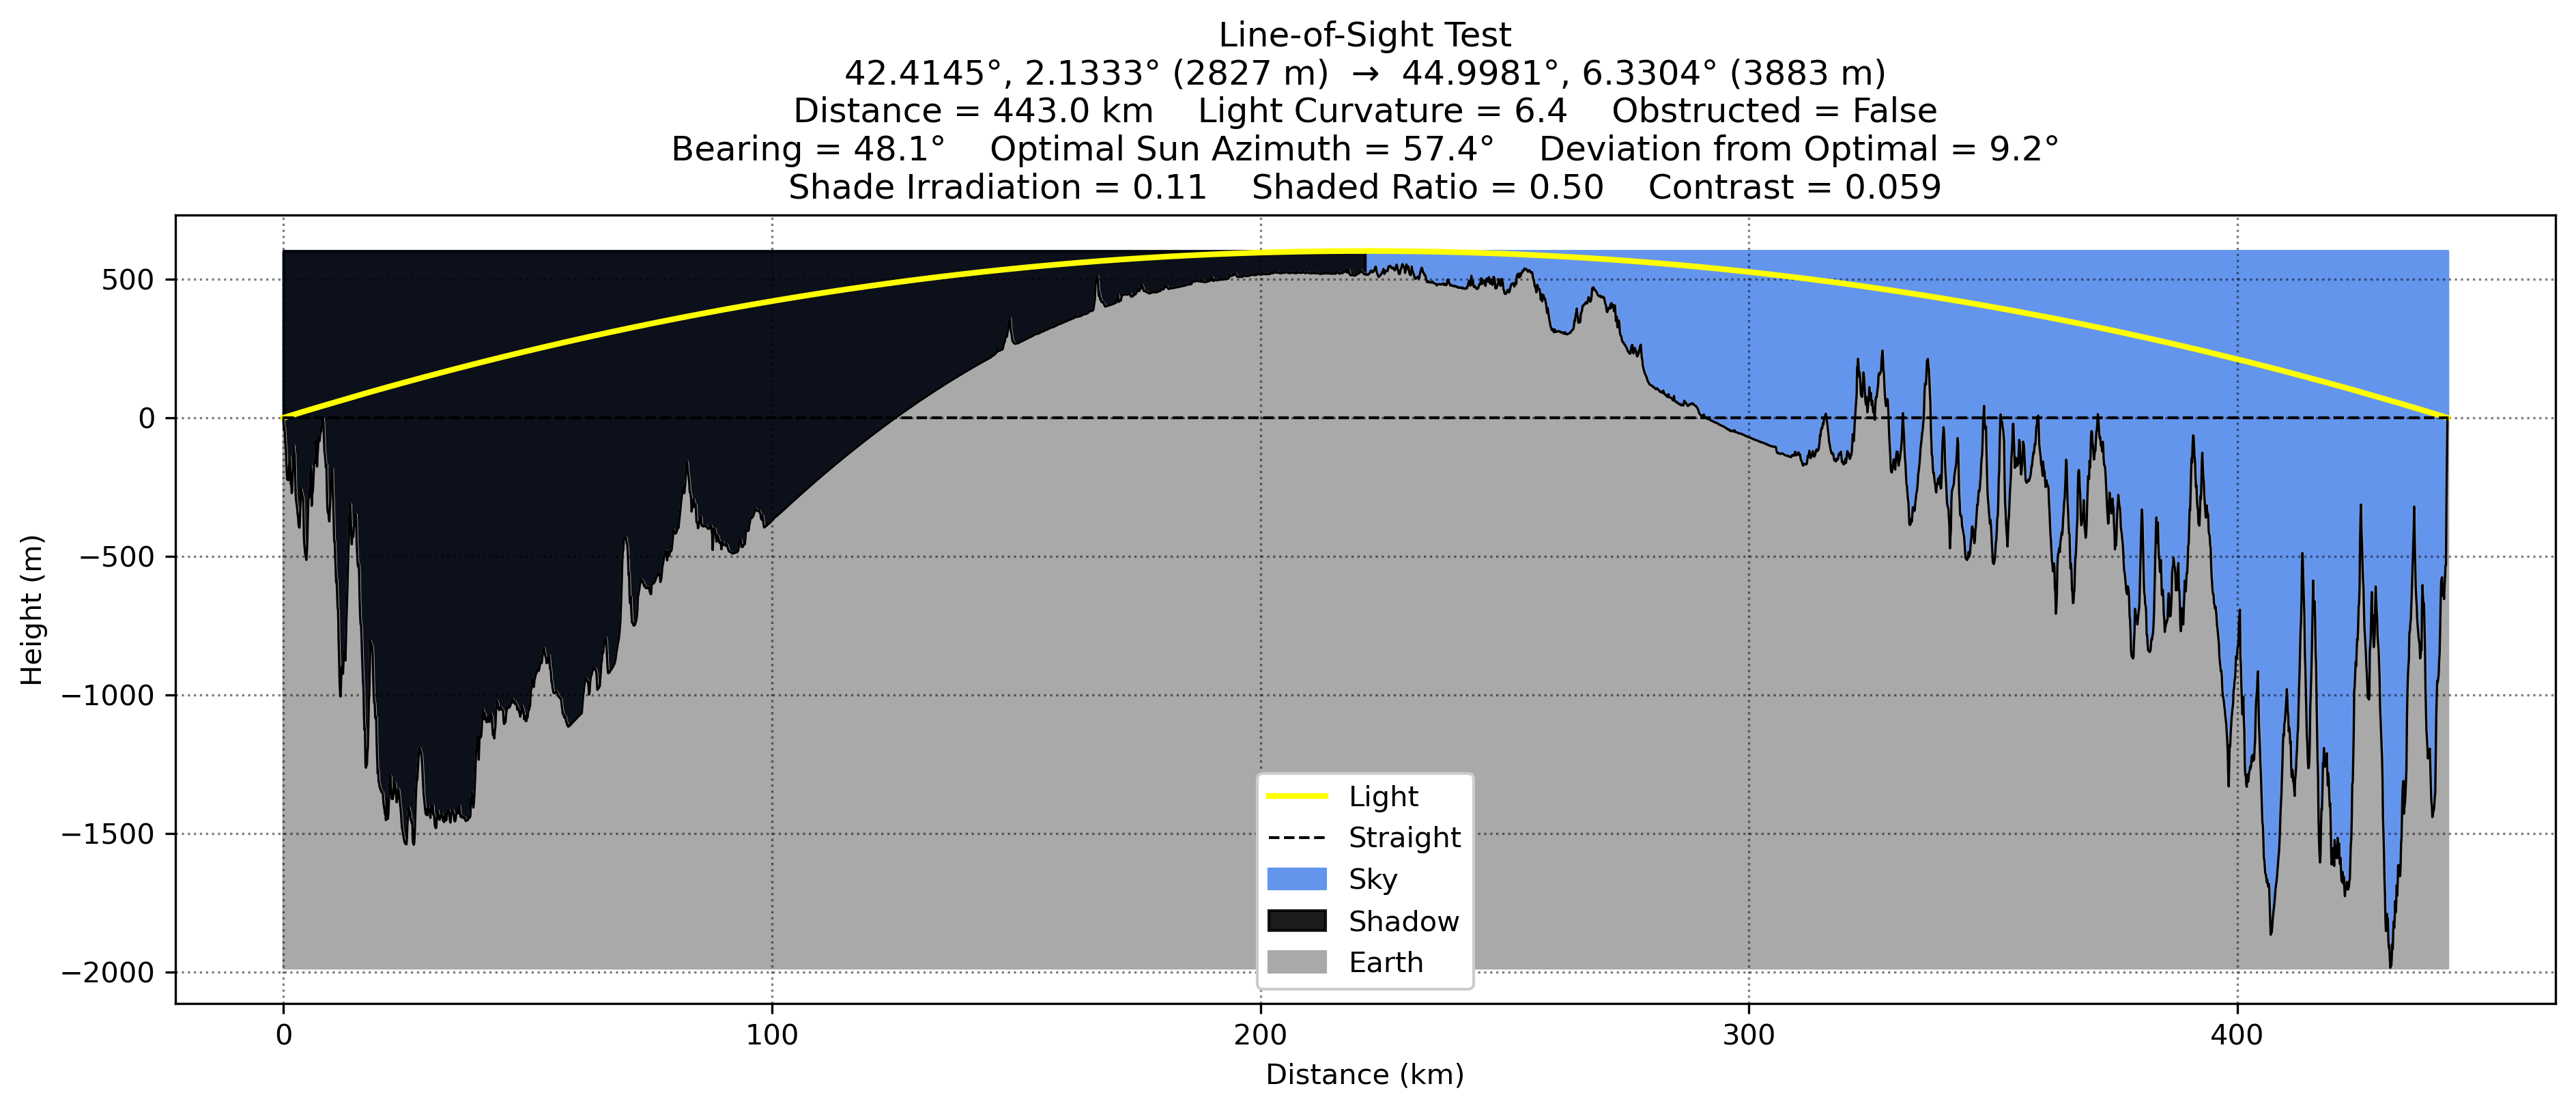

In [14]:
obs = me.Summit(42.414475, 2.133279, 2827)
trg = me.Summit(44.99811, 6.33042, 3883)
los = me.LineOfSight(obs, trg)

los.process_full_line_of_sight()

los.plot(legend_location='lower center', plot_path='../misc/images/longest_los_confirmed')

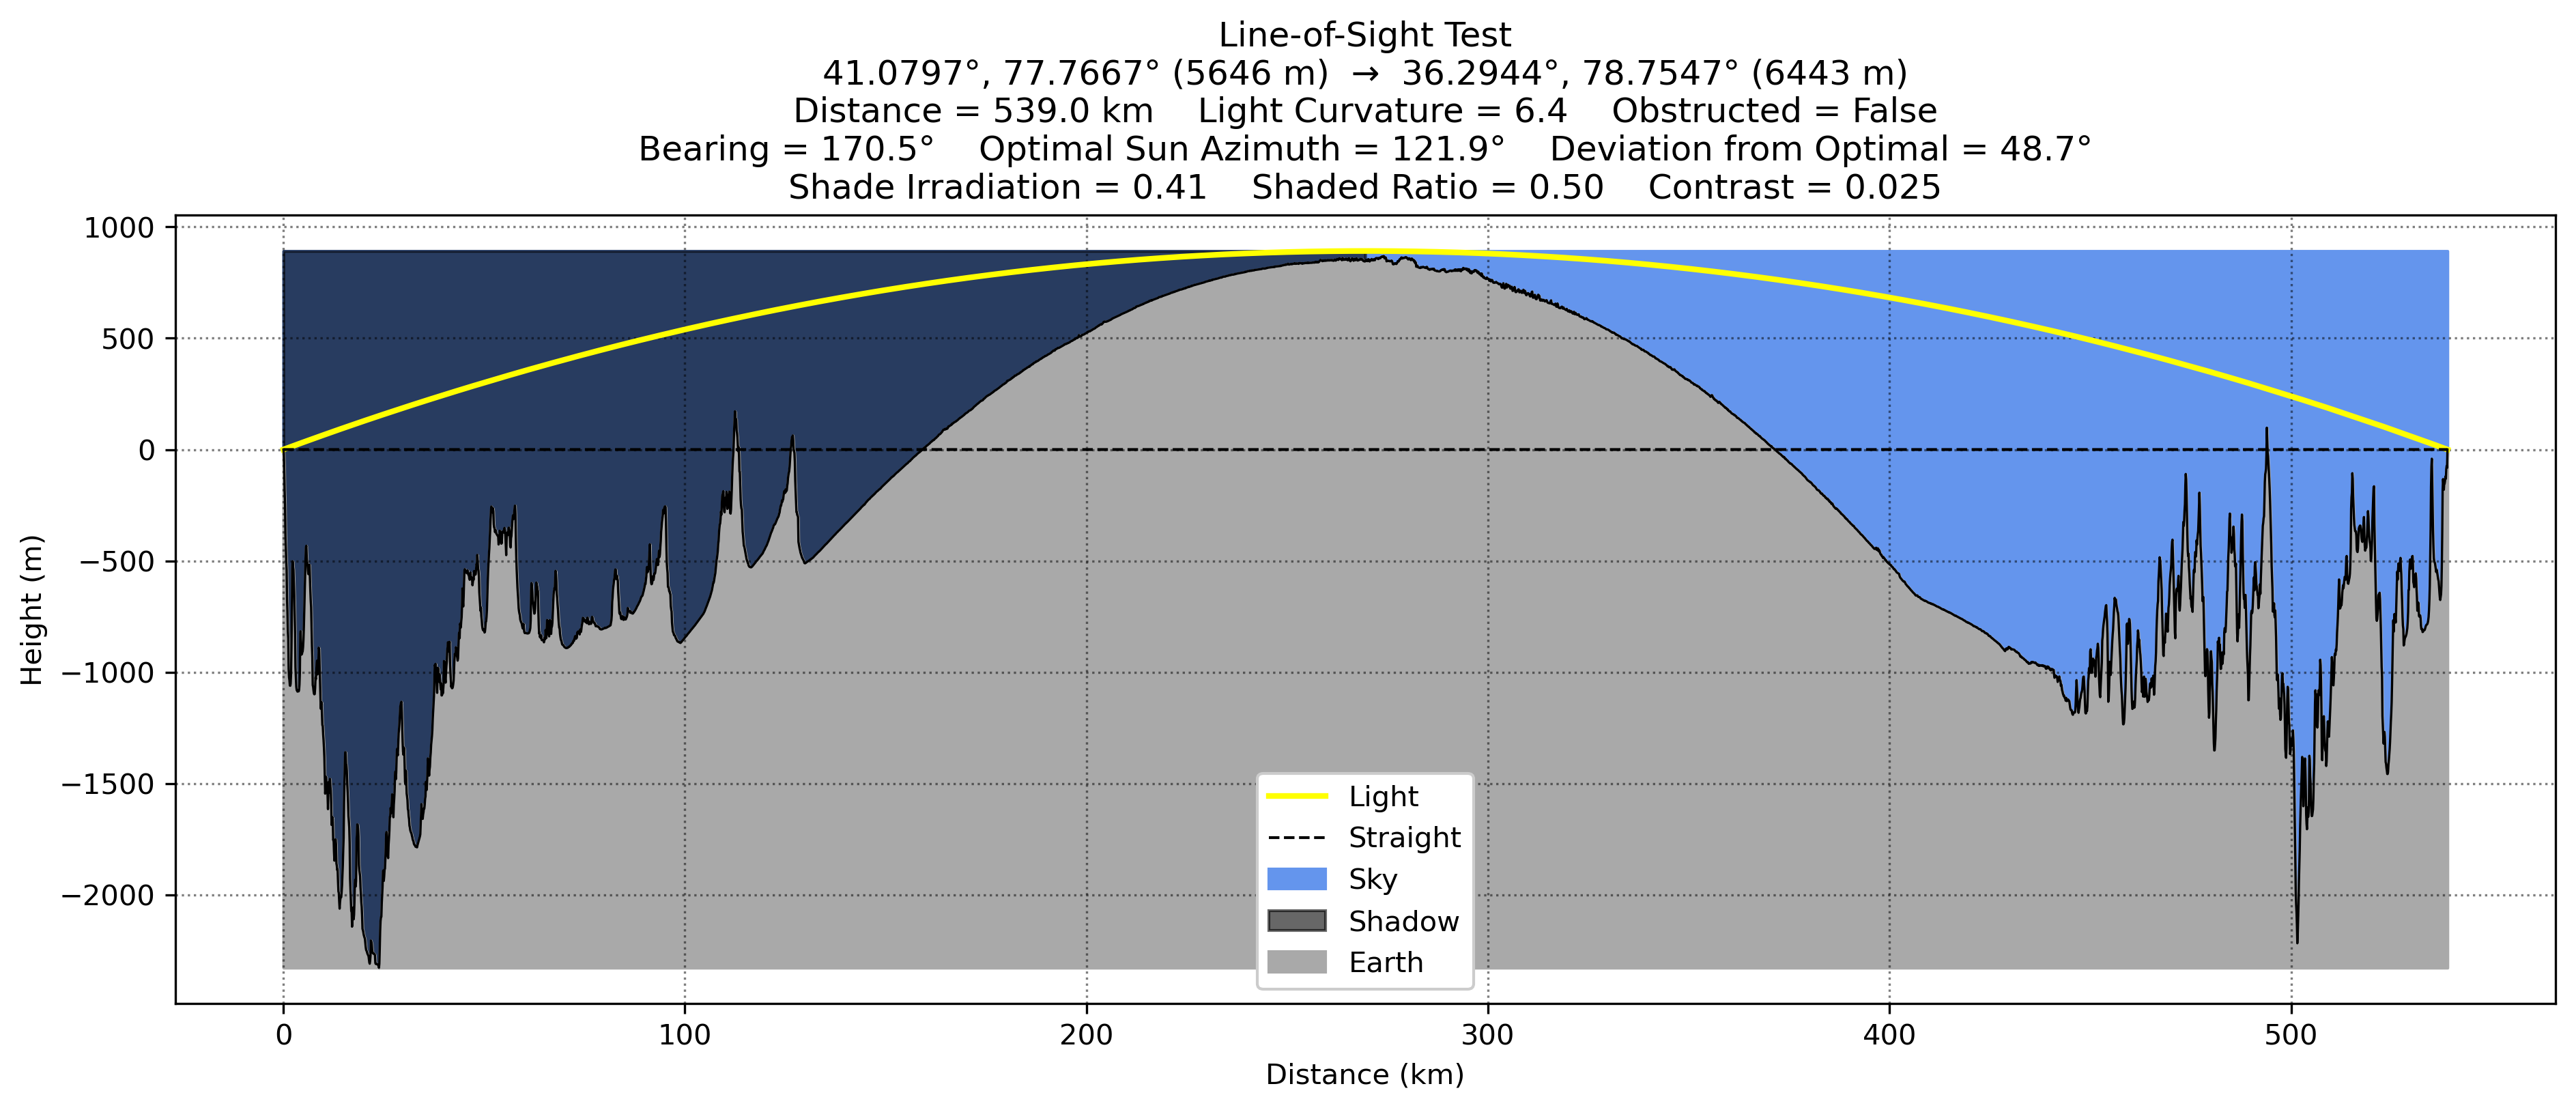

In [15]:
obs = me.Summit(41.0797, 77.7667, 5646)
trg = me.Summit(36.2944, 78.7547, 6443)
los = me.LineOfSight(obs, trg)

los.process_full_line_of_sight()

los.plot(legend_location='lower center', plot_path='../misc/images/longest_los_JGB')

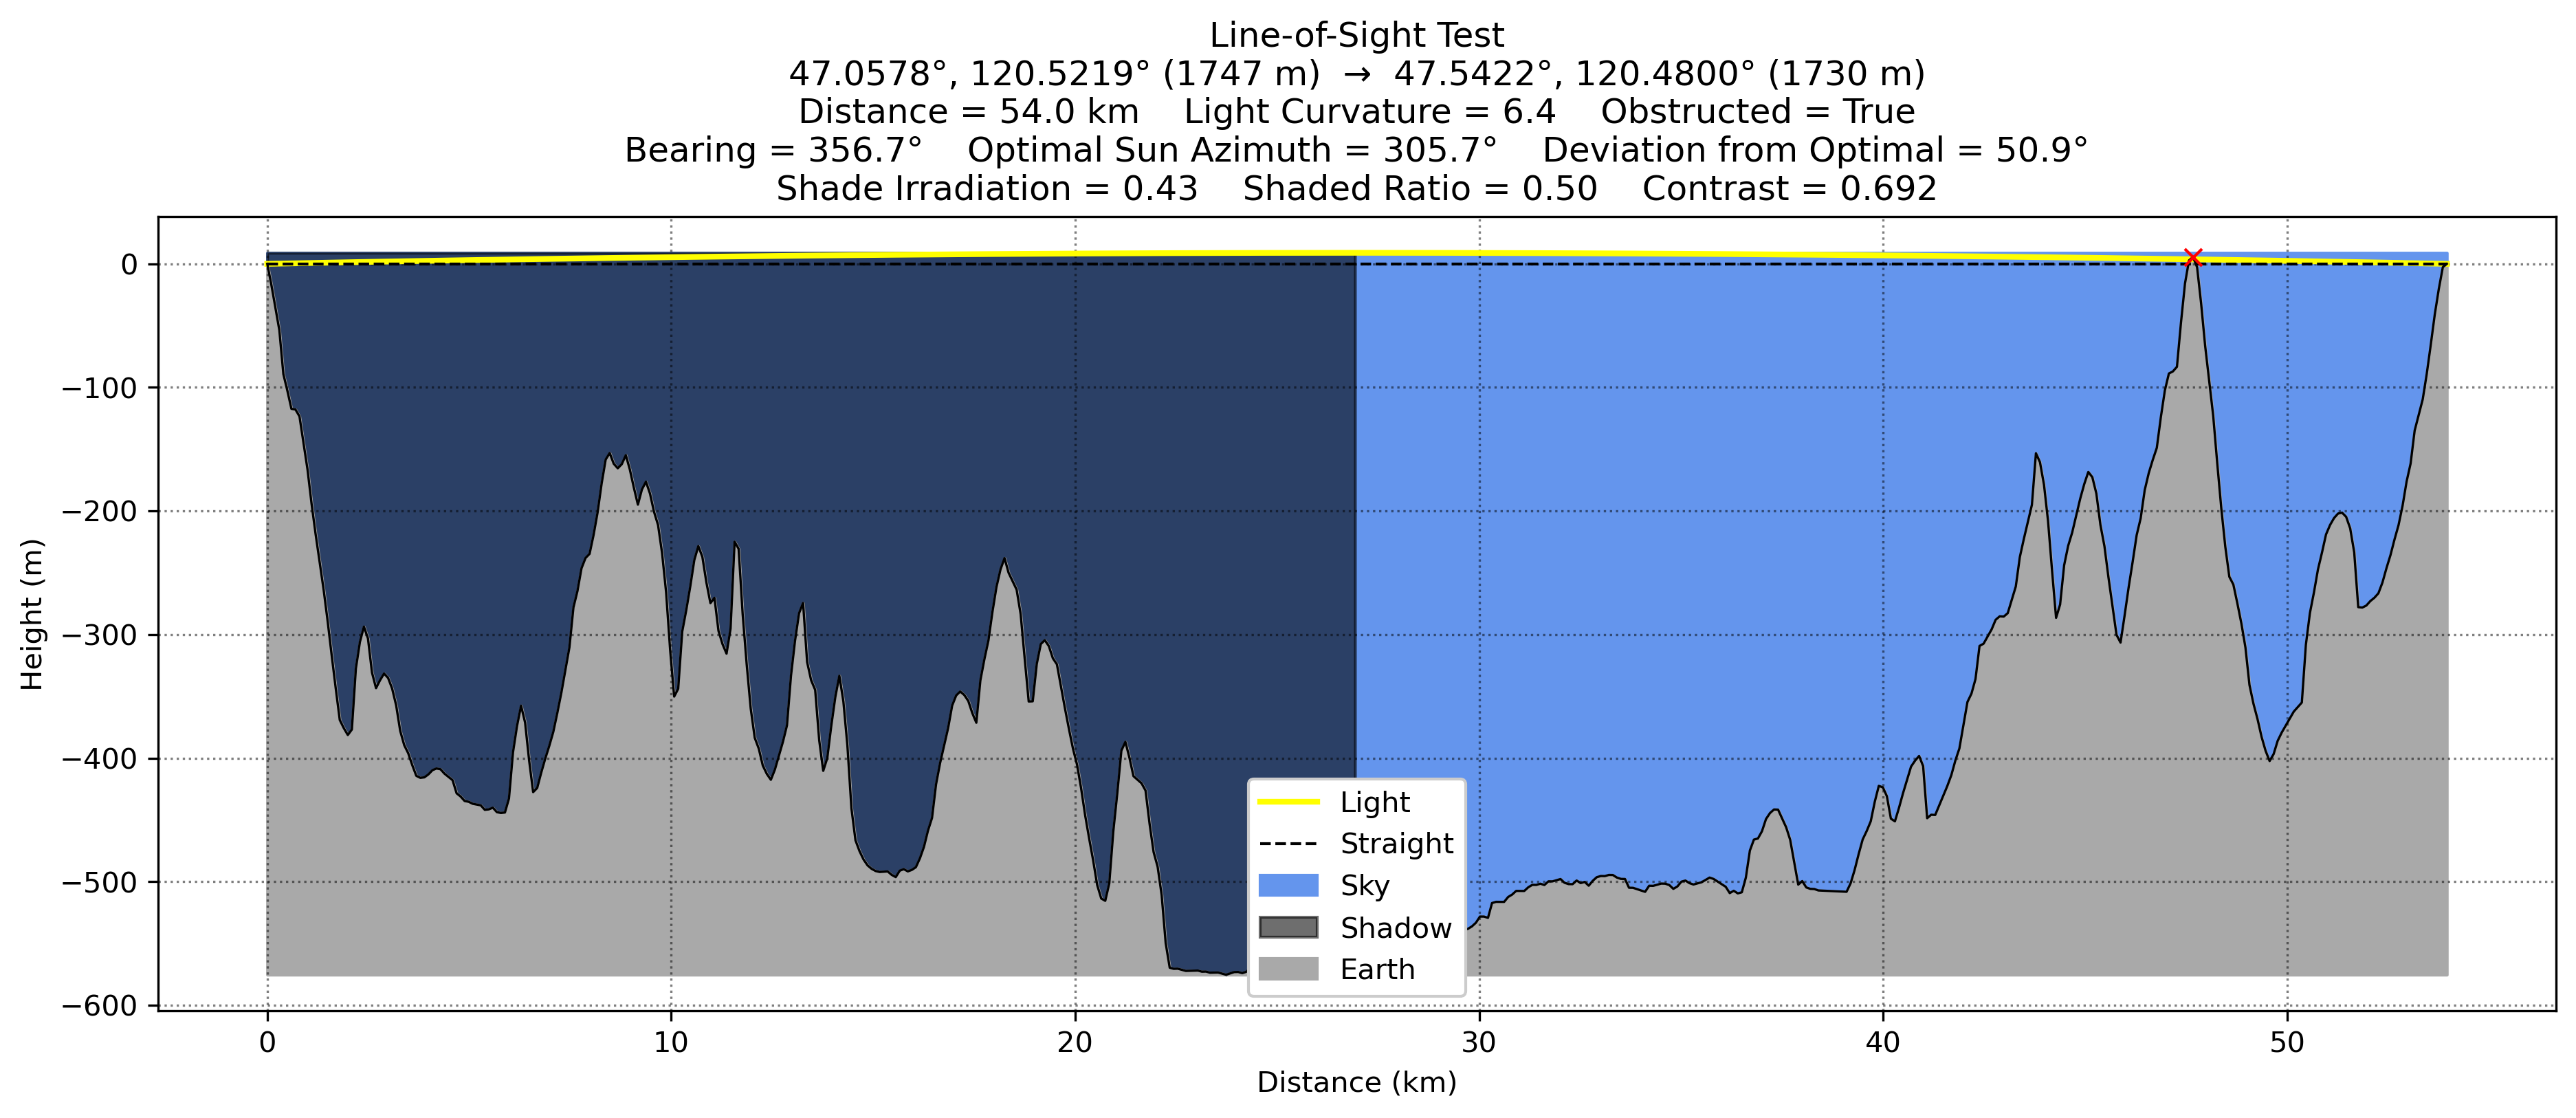

In [16]:
obs = me.Summit(47.0578, 120.5219, 1747)
trg = me.Summit(47.5422, 120.48, 1730)
los = me.LineOfSight(obs, trg)

los.process_full_line_of_sight()

los.plot(legend_location='lower center')

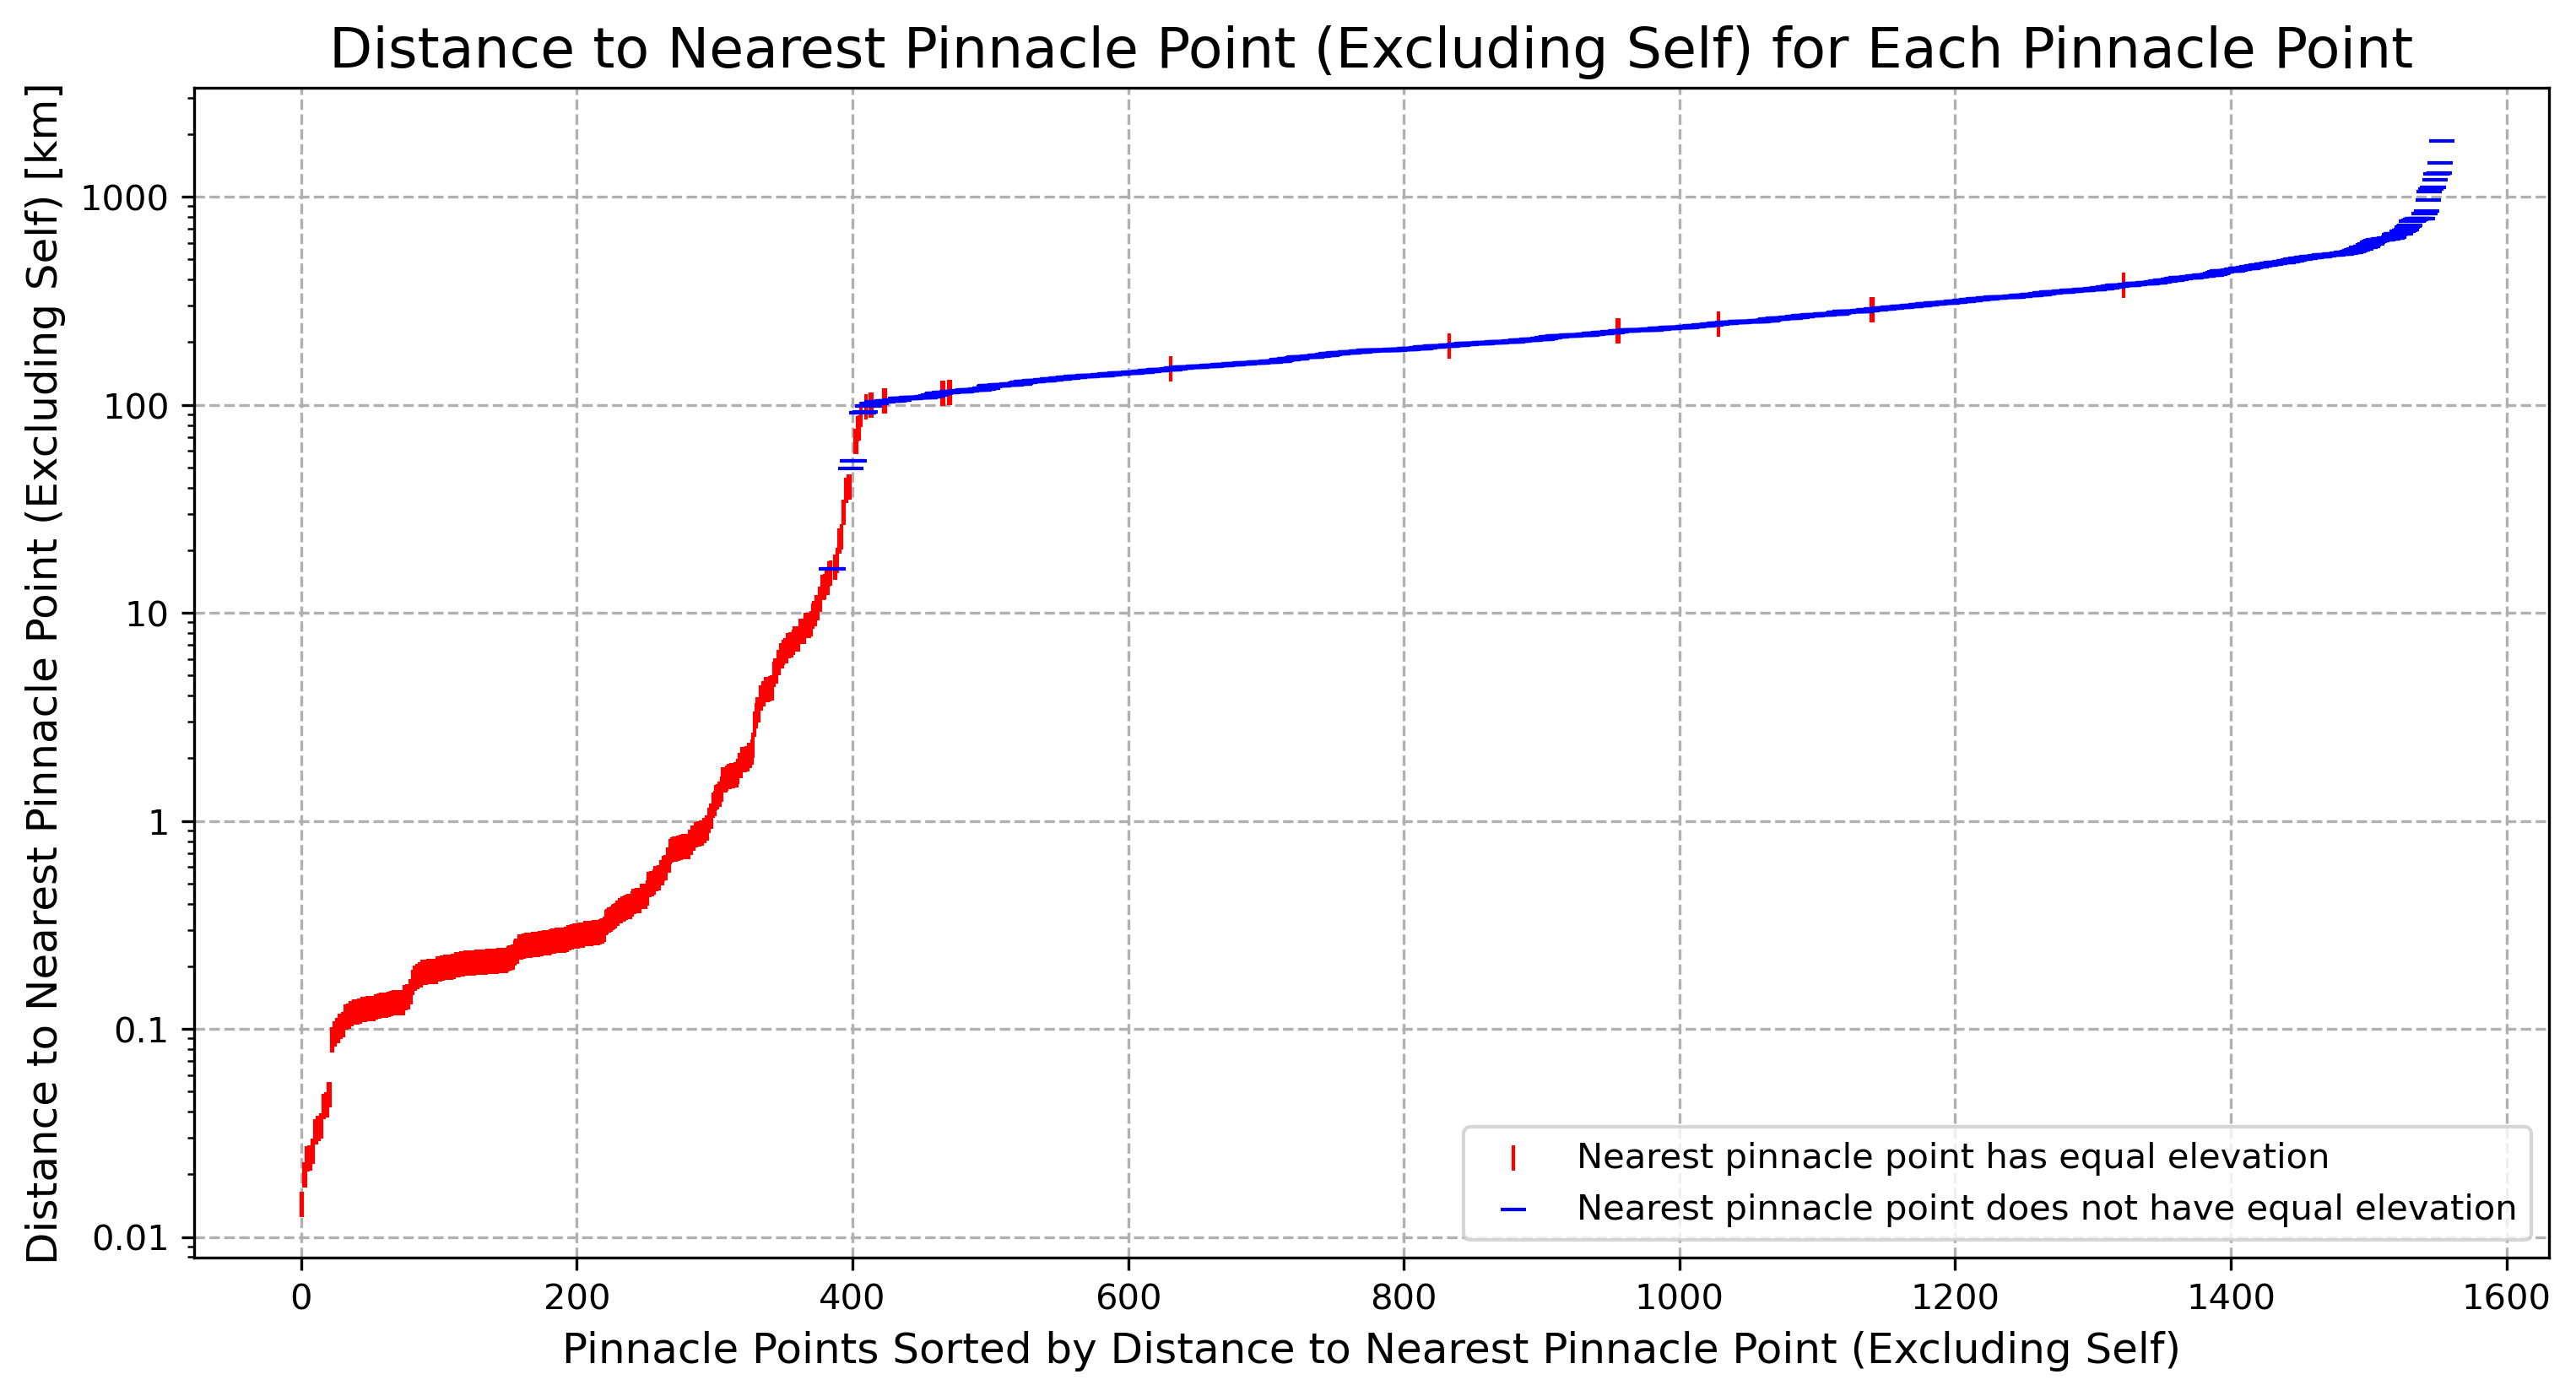

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

pinnacle_points = pd.read_csv("../data/results/pinnacle_points/prm_iso/pinnacle_points.csv")

def distance(lat1, lon1, lat2, lon2):
    return me.geod.line_length([lon2, lon1], [lat2, lat1])

def find_nearest(row, df):
    # compute distances to all other points
    distances = df.apply(
        lambda r: distance(row.latitude, row.longitude, r.latitude, r.longitude) if r.summit_id != row.summit_id else np.inf,
        axis=1
    )
    # index of the minimum distance
    idx_min = distances.idxmin()
    return pd.Series({
        "closest_id": df.loc[idx_min, "summit_id"],
        "closest_dist_km": distances[idx_min],
        "closest_elv": df.loc[idx_min, "elevation"]
    })

pinnacle_points[["closest_id", "closest_dist", "closest_elv"]] = pinnacle_points.apply(find_nearest, df=pinnacle_points, axis=1)

pinnacle_points = pinnacle_points.sort_values("closest_dist")
x = range(len(pinnacle_points))

mask = pinnacle_points["closest_elv"] == pinnacle_points["elevation"]

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

ax.scatter([i for i, m in zip(x, mask) if m],
           pinnacle_points["closest_dist"].divide(1000)[mask], 
           s=50, marker='|', color='red', zorder=2, 
           linewidth=1,
           label="Nearest pinnacle point has equal elevation")

ax.scatter([i for i, m in zip(x, mask) if not m],
           pinnacle_points["closest_dist"].divide(1000)[~mask], 
           s=50, marker='_', color='blue', zorder=2,
           linewidth=1, 
           label="Nearest pinnacle point does not have equal elevation")

ax.set_yscale("log")
ax.grid(True, which="major", ls="--", zorder=0)

fig.patch.set_facecolor("white")

ax.set_title("Distance to Nearest Pinnacle Point (Excluding Self) for Each Pinnacle Point", fontsize=16)
ax.set_xlabel("Pinnacle Points Sorted by Distance to Nearest Pinnacle Point (Excluding Self)", fontsize=12)
ax.set_ylabel("Distance to Nearest Pinnacle Point (Excluding Self) [km]", fontsize=12)

ax.set_yticks([0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels(["0.01", "0.1", "1", "10", "100", "1000"])

ax.legend(loc=4, facecolor="white")
fig.savefig("../misc/images/distance_to_nearest_pinnacle_point", bbox_inches="tight")
plt.show()

In [18]:
observer = me.Summit(
    summit_id = -454766,
    latitude = 69.2775, 
    longitude = -144.91,
    elevation = 2712)

observer.is_pinnacle_point()

Potential Disqualifying Summits: 1
Tested Potential Disqualifying Summits: 1
In view of 69.2025, -143.8011 (2721 m) 44 km away
Pinnacle Point: False


False

In [17]:
me.get_elevations([69.2775], [-144.91])[0]

2670.0

1554

In [29]:
pinnacle_points = pd.read_csv("../data/results/pinnacle_points/prm_iso/pinnacle_points.csv")
len(pinnacle_points)
# pinnacle_points.head()

1554